> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy numpy


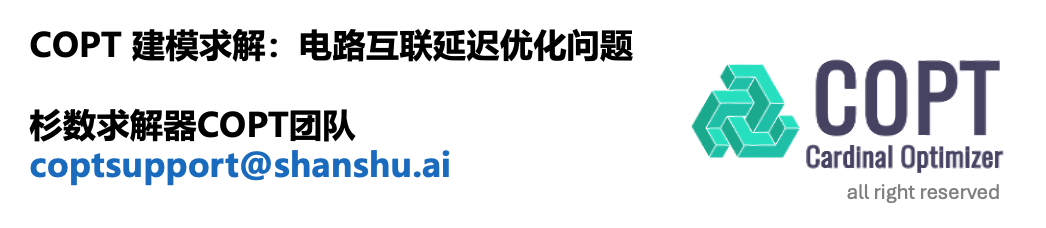

# 电路互联延迟优化问题代码实现
## 使用COPT建模求解电路互联延迟优化问题的步骤

1. 导入COPT-Python接口库 `coptpy`

2. 添加/导入模型**数据**

3. 创建**COPT求解环境**和**COPT求解模型**

4. 构建模型，依次添加**模型三要素**
- 添加**决策变量**：可以通过批量添加的建模方式高效添加多维变量
- 设置**目标函数**：使用辅助变量构造三个不等式约束来代替最大值函数
- 添加**约束条件**：可以通过使用`nl`命名空间构建非线性表达式，使用`Model.addNLConstr()`来将非线性表达式添加到约束中
- （添加**指数锥**：`Model.addExpCone([x,y,z], COPT.EXPCONE_PRIMAL)` 需要标准型（输入变量为单个元素）；`Model.addAffineCone()` 可接收仿射锥形式输入， 先通过 `AffineConeBuilder` 类构造实例化的仿射锥对象，以添加较为复杂的指数锥）
5. **求解**

6. 查看、分析**结果**

<font color=#0000FF>
<b>注意：使用COPT的仿射锥和指数锥模块，要求COPT为7.2.4及以上版本。</b>
</font>

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT, nl
import numpy as np

## 添加模型数据

In [6]:
C_load1 = 1.5
C_load2 = 1
C_load3 = 5
k0 = 1.0
rho = 1.0

## 问题一：非线性模块求解
我们直接求解带有非凸非线性约束的问题。

## 创建模型
创建名为`interconnect_sizing_1`的模型`model_1`

In [9]:
env = cp.Envr()
model_1 = env.createModel("interconnect_sizing_1")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量
添加决策变量 $w_i$ ，其中 $w_i \in [0.1,\ 10],\ i \in W\_index$；添加决策变量 $T$ 。

In [11]:
# 添加导线编号 1-6
W_index = list(range(1, 7))

# 添加变量 w1 ,..., w6 表示线宽，取值范围为 [0.1, 10]
w = model_1.addVars(W_index, lb=0.1, ub=10.0, nameprefix="w")

# 添加变量 T 作为最大延迟
T = model_1.addVar(name="T")

### 设置目标函数
目标函数为
$$
\min_{w_i}\ T
$$

In [13]:
# 最小化 T
model_1.setObjective(T, sense=COPT.MINIMIZE)

### 添加约束条件
添加三个负载延迟的表达式 $T_{load1}$， $T_{load2}$， $T_{load3}$ 。
$$
C_i = k_0\ w_i
$$
$$
R_i = \frac{\rho}{w_i}
$$
$$
\begin{aligned}
T_{load1} &= (C_3+C_{load1})(R_1+R_2+R_3)+C_2(R_1+R_2)+(C_1+C_4+C_5+C_{load2}+C_6+C_{load3})R_1 \\
T_{load2} &= (C_5+C_{load2})(R_1+R_4+R_5)+(C_4+C_6+C_{load3})(R_1+R_4)+(C_1+C_2+C_3+C_{load1})R_1 \\
T_{load3} &= (C_6+C_{load3})(R_1+R_4+R_6)+(C_4+C_5+C_{load2})(R_1+R_4)+(C_1+C_2+C_3+C_{load1})R_1 \\
\end{aligned}
$$
添加最大负载延迟 $T$ 不小于任何一个负载延迟 $T_{load1}$、 $T_{load2}$、 $T_{load3}$ 的三个约束
$$
T \geq T_{load1}
$$
$$
T \geq T_{load2}
$$
$$
T \geq T_{load3}
$$

<font color=#0000FF>
<b>提示：构建模型中的非线性约束</b>
</font>

目前COPT的原生编程语言建模接口支持在目标和约束中直接添加非线性函数表达式。以COPT-Python接口为例，可以使用四则运算和nl命名空间中的非线性函数来构造非线性表达式，如使用`nl.pow()`表示幂函数、`nl.abs()`表示绝对值函数、`nl.sin()`表示正弦函数、`nl.exp()`表示自然指数函数、`nl.sqrt()`表示平方根函数等。

- `addNlConstr(lhs, sense=None, rhs=None, name="")`：可以添加一个非线性约束到模型中，其中若`lhs`是非线性表达式类型，则必须同时提供`sense`和`rhs`分别表示约束方向和右端项。

其他可支持的非线性运算函数及添加非线性约束的详细信息可参考 [《COPT用户手册：Python API》](https://guide.coap.online/copt/zh-doc/pyapiref.html)

In [16]:
# 电阻 R[i] = rho / w[i]
R = {i: rho / w[i] for i in W_index}

# 电容 C[i] = k0 * w[i]
C = {i: k0 * w[i] for i in W_index}


# 延迟表达式构建
T_load1 = (C[3] + C_load1) * (R[1] + R[2] + R[3]) + \
          C[2] * (R[1] + R[2]) + \
          (C[1] + C[4] + C[5] + C_load2 + C[6] + C_load3) * R[1]

T_load2 = (C[5] + C_load2) * (R[1] + R[4] + R[5]) + \
          (C[4] + C[6] + C_load3) * (R[1] + R[4]) + \
          (C[1] + C[2] + C[3] + C_load1) * R[1]

T_load3 = (C[6] + C_load3) * (R[1] + R[4] + R[6]) + \
          (C[4] + C[5] + C_load2) * (R[1] + R[4]) + \
          (C[1] + C[2] + C[3] + C_load1) * R[1]

# 添加非线性约束：T ≥ T_load1, T ≥ T_load2, T ≥ T_load3 ，实现 T = max{T_load1, T_load2, T_load3}
model_1.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load1, name="T_load1_constraint")
model_1.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load2, name="T_load2_constraint")
model_1.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load3, name="T_load3_constraint")

<coptpy.NlConstraint: T_load3_constraint>

## 求解

In [18]:
model_1.solve()

Model fingerprint: 2e7f30dd

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an NLP problem

The original problem has:
    0 rows, 7 columns and 0 non-zero elements
    3 nonlinear expression constraints

The presolved problem has:
    0 rows, 7 columns and 0 non-zero elements
    3 nonlinear expression constraints

Starting NLP barrier solver using 4 threads

Iter     Objective            Compl       Primal.Inf         Dual.Inf       Time
   0  +9.99999000e-03  +9.79000011e+00  +1.78171833e+02  +9.99996804e-01   0.00s
   1  +1.00041666e-01  +7.14084013e+00  +9.12405502e+01  +7.34709645e-01   0.00s
   2  +1.00673776e-01  +7.62011761e-01  +4.74404908e+01  +7.55688506e-01   0.00s
   3  +1.03434675e-01  +3.79288606e-01  +2.62426196e+01  +2.96701907e-01   0.01s
   4  +1.06277675e-01  +1.16179929e-01  +1.83600399e

## 获取结果

In [20]:
if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    print("Optimal T = {0:.3f}".format(T.X))
    print("Widths:")
    vars = model_1.getVars()
    for var in vars:
        if var.name.startswith("w"):
            print(" {0} = {1:.3f}".format(var.name, var.x))
else:
    print("Solve failed with status:", model_1.status)

Optimal T = 7.920
Widths:
 w(1) = 10.000
 w(2) = 2.355
 w(3) = 1.274
 w(4) = 9.421
 w(5) = 0.849
 w(6) = 4.246


## 问题二：指数锥模块求解
我们将原问题转化为带有指数锥约束的优化问题。
## 创建模型
创建名为`interconnect_sizing_2`的模型`model_2`。

In [22]:
env = cp.Envr()
model_2 = env.createModel("interconnect_sizing_2")
model_2.matrixmodelmode = "experimental"

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量
添加决策变量 $y_i$ ，其中 $y_i \in [\ln 0.1,\ \ln 10],\ i \in W\_index$；添加决策变量 $T$ 。

添加模型的辅助变量 $t\_load1$ 、 $t\_load2$ 、 $t\_load3$ 、 $\{u\_load1_i\}^{14}_{i=1}$ 、 $\{u\_load2_j\}^{16}_{j=1}$ 、 $\{u\_load3_k\}^{16}_{k=1}$ 、 $one$ 。

其中对于 $one$ 我们设置其上下界均为 $1$ 来将其值设置为 $1$。

In [24]:
# 添加导线编号 1-6
W_index = list(range(1, 7))
# 添加线宽的对数，即变量 y[1] ,..., y[6]，y[i] = ln(w[i])
y = model_2.addVars(W_index, lb=np.log(0.1), ub=np.log(10.0), nameprefix="y")
# 添加变量 T 代表最大延迟
T = model_2.addVar(name="T")

# 添加辅助变量
t_load1 = model_2.addVar(name="t_load1")
t_load2 = model_2.addVar(name="t_load2")
t_load3 = model_2.addVar(name="t_load3")
u_load1 = model_2.addVars(14, nameprefix="u_load1", lb=0, ub=1)
u_load2 = model_2.addVars(16, nameprefix="u_load2", lb=0, ub=1)
u_load3 = model_2.addVars(16, nameprefix="u_load3", lb=0, ub=1)
one = model_2.addVar(lb=1.0, ub=1.0, name="one")

### 设置目标函数
目标函数为
$$
\min_{\mathbf{y}}\ T
$$

In [26]:
# 最小化 T
model_2.setObjective(T, sense=COPT.MINIMIZE)

### 添加约束条件
$T$ 是信号传播到三个终端负载的最大延迟。
$$
\begin{cases}
(T,\ 1,\ t\_{load1}) \in K_{\text{exp}} \\
\sum_{i=1}^{14} u\_{load1}_i = 1 \\
(u\_{load1}_i,\ 1,\ \mathbf{a\_{load1}_i^{\top}} \cdot \mathbf{y} + b\_{load1}_i - t\_{load1} ) \in K_{\text{exp}}\ ,\ i = 1,\ \cdots ,14
\end{cases}
$$
$$
\begin{cases}
(T,\ 1,\ t\_{load2}) \in K_{\text{exp}} \\
\sum_{j=1}^{16} u\_{load2}_j = 1 \\
(u\_{load2}_j,\ 1,\ \mathbf{a\_{load2}_j^{\top}} \cdot \mathbf{y} + b\_{load2}_j - t\_{load2} ) \in K_{\text{exp}}\ ,\ j = 1,\ \cdots ,16
\end{cases}
$$
$$
\begin{cases}
(T,\ 1,\ t\_{load3}) \in K_{\text{exp}} \\
\sum_{k=1}^{16} u\_{load3}_k = 1 \\
(u\_{load3}_k,\ 1,\ \mathbf{a\_{load3}_k^{\top}} \cdot \mathbf{y} + b\_{load3}_k - t\_{load3} ) \in K_{\text{exp}}\ ,\ k = 1,\ \cdots ,16
\end{cases}
$$

1. 添加三个标准指数锥约束，使用COPT求解器构造并添加指数锥约束时，需要将变量以 `vars = [x_1,x_2,x_3]` 的标准格式输入，即要求构成指数锥的元素需要为单个变量（而不是线性表达式或常数），故将常数 1 替换为辅助变量`one`；
$$
(T,\ one,\ t\_{load1}) \in K_{\text{exp}}
$$
$$
(T,\ one,\ t\_{load2}) \in K_{\text{exp}}
$$
$$
(T,\ one,\ t\_{load3}) \in K_{\text{exp}}
$$

In [29]:
model_2.addExpCone([T, one, t_load1], COPT.EXPCONE_PRIMAL)
model_2.addExpCone([T, one, t_load2], COPT.EXPCONE_PRIMAL)
model_2.addExpCone([T, one, t_load3], COPT.EXPCONE_PRIMAL)

<coptpy.ExpCone>

2. 添加辅助变量 $\{u\_load1_i\}^{14}_{i=1}$ 、 $\{u\_load2_j\}^{16}_{j=1}$ 及 $\{u\_load3_k\}^{16}_{k=1}$ 总和均为 1 的约束；

In [31]:
model_2.addConstr(cp.quicksum(u_load1) == 1)
model_2.addConstr(cp.quicksum(u_load2) == 1)
model_2.addConstr(cp.quicksum(u_load3) == 1)

<coptpy.Constraint: >

3. 添加 $T_{load1}$ 、 $T_{load2}$ 、 $T_{load3}$ 表达式中每一项的指数和系数的对数，构造仿射锥约束。
如下是展开后的延迟表达式及其对应的 $log\text{-}sum\text{-}exp$ 形式
$$
\begin{aligned}
T_{load1} =\ & k_0 \rho w_1^{-1} w_3 + k_0 \rho w_2^{-1} w_3 + k_0 \rho + \rho C_{load1} w_1^{-1} + \rho C_{load1} w_2^{-1} + \rho C_{load1} w_3^{-1} + \\
 & k_0 \rho w_1^{-1} w_2 + k_0 \rho \ + \\
 & k_0 \rho + k_0 \rho w_1^{-1} w_4 + k_0 \rho w_1^{-1} w_5 + \rho C_{load2} w_1^{-1} + k_0 \rho w_1^{-1} w_6 + \rho C_{load3} w_1^{-1} \\
T_{load1} =\ & \sum_{i=1}^{14} e^{\mathbf{a\_load1_i^{\top}} \cdot \mathbf{y} + b\_load1_i} \\
\end{aligned}
$$
$$
\begin{aligned}
T_{load2} =\ & k_0 \rho w_1^{-1} w_5 + k_0 \rho w_4^{-1} w_5 + k_0 \rho + \rho C_{load2} w_1^{-1} + \rho C_{load2} w_4^{-1} + \rho C_{load2} w_5^{-1} + \\
 & k_0 \rho w_1^{-1} w_4 + k_0 \rho \ + k_0 \rho w_1^{-1} w_6 + k_0 \rho w_4^{-1} w_6 + \rho C_{load3} w_1^{-1} + \rho C_{load3} w_4^{-1} + \\
 & k_0 \rho + k_0 \rho w_1^{-1} w_2 + k_0 \rho w_1^{-1} w_3 + \rho C_{load1} w_1^{-1} \\
T_{load2} =\ & \sum_{j=1}^{16} e^{\mathbf{a\_load2_j^{\top}} \cdot \mathbf{y} + b\_load2_j} \\
\end{aligned}
$$
$$
\begin{aligned}
T_{load3} =\ & k_0 \rho w_1^{-1} w_6 + k_0 \rho w_4^{-1} w_6 + k_0 \rho + \rho C_{load3} w_1^{-1} + \rho C_{load3} w_4^{-1} + \rho C_{load3} w_6^{-1} + \\
 & k_0 \rho w_1^{-1} w_4 + k_0 \rho \ + k_0 \rho w_1^{-1} w_5 + k_0 \rho w_4^{-1} w_5 + \rho C_{load2} w_1^{-1} + \rho C_{load2} w_4^{-1} + \\
 & k_0 \rho + k_0 \rho w_1^{-1} w_2 + k_0 \rho w_1^{-1} w_3 + \rho C_{load1} w_1^{-1} \\
T_{load3} =\ & \sum_{k=1}^{16} e^{\mathbf{a\_load3_k^{\top}} \cdot \mathbf{y} + b\_load3_k} \\
\end{aligned}
$$

In [33]:
A_load1 = [[-1, 0, 1, 0, 0, 0],
           [0, -1, 1, 0, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0],
           [0, -1, 0, 0, 0, 0],
           [0, 0, -1, 0, 0, 0],
           [-1, 1, 0, 0, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 1, 0, 0],
           [-1, 0, 0, 0, 1, 0],
           [-1, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 1],
           [-1, 0, 0, 0, 0, 0]]
B_load1 = np.log(np.array([k0*rho, k0*rho, k0*rho, C_load1*rho, C_load1*rho, C_load1*rho,
                           k0*rho, k0*rho,
                           k0*rho, k0*rho, k0*rho, C_load2*rho, k0*rho, C_load3*rho]))
A_load2 = [[-1, 0, 0, 0, 1, 0],
           [0, 0, 0, -1, 1, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0],
           [0, 0, 0, -1, 0, 0],
           [0, 0, 0, 0, -1, 0],
           [-1, 0, 0, 1, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 1],
           [0, 0, 0, -1, 0, 1],
           [-1, 0, 0, 0, 0, 0],
           [0, 0, 0, -1, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 1, 0, 0, 0, 0],
           [-1, 0, 1, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0]]
B_load2 = np.log(np.array([k0*rho, k0*rho, k0*rho, C_load2*rho, C_load2*rho, C_load2*rho,
                           k0*rho, k0*rho, k0*rho, k0*rho, C_load3*rho, C_load3*rho,
                           k0*rho, k0*rho, k0*rho, C_load1*rho]))
A_load3 = [[-1, 0, 0, 0, 0, 1],
           [0, 0, 0, -1, 0, 1],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0],
           [0, 0, 0, -1, 0, 0],
           [0, 0, 0, 0, 0, -1],
           [-1, 0, 0, 1, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 1, 0],
           [0, 0, 0, -1, 1, 0],
           [-1, 0, 0, 0, 0, 0],
           [0, 0, 0, -1, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 1, 0, 0, 0, 0],
           [-1, 0, 1, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0]]
B_load3 = np.log(np.array([k0*rho, k0*rho, k0*rho, C_load3*rho, C_load3*rho, C_load3*rho,
                           k0*rho, k0*rho, k0*rho, k0*rho, C_load2*rho, C_load2*rho,
                           k0*rho, k0*rho, k0*rho, C_load1*rho]))

我们希望添加的原始仿射形式指数约束为
$$
(u\_{load1}_i,\ 1,\ \mathbf{a\_{load1}_i^{\top}} \cdot \mathbf{y} + b\_{load1}_i - t\_{load1} ) \in K_{\text{exp}}\ ,\ i = 1,\ \cdots ,14
$$
$$
(u\_{load2}_j,\ 1,\ \mathbf{a\_{load2}_j^{\top}} \cdot \mathbf{y} + b\_{load2}_j - t\_{load2} ) \in K_{\text{exp}}\ ,\ j = 1,\ \cdots ,16
$$
$$
(u\_{load3}_k,\ 1,\ \mathbf{a\_{load3}_k^{\top}} \cdot \mathbf{y} + b\_{load3}_k - t\_{load3} ) \in K_{\text{exp}}\ ,\ k = 1,\ \cdots ,16
$$
自COPT 7.2.4起，**COPT新增了对于仿射锥建模的支持，便于用户对复杂的锥约束进行建模。构成锥的元素可以为线性表达式或者常数，无需再通过增加辅助变量进行标准型转化**。因此，这里我们展示直接添加仿射形式的指数锥约束的方式，可以有效控制问题变量规模，并且建模友好，与上述的代数形式十分接近。

In [35]:
for i in range(14):
    expr = cp.LinExpr()
    expr.addTerms(y.values(), A_load1[i])
    afcone_1 = cp.AffineConeBuilder()
    afcone_1.setBuilder(COPT.EXPCONE_PRIMAL, [u_load1[i], 1, expr + B_load1[i] - t_load1])
    model_2.addAffineCone(afcone_1)
for j in range(16):
    expr = cp.LinExpr()
    expr.addTerms(y.values(), A_load2[j])
    afcone_2 = cp.AffineConeBuilder()
    afcone_2.setBuilder(COPT.EXPCONE_PRIMAL, [u_load2[j], 1, expr + B_load2[j] - t_load2])
    model_2.addAffineCone(afcone_2)
for k in range(16):
    expr = cp.LinExpr()
    expr.addTerms(y.values(), A_load3[k])
    afcone_3 = cp.AffineConeBuilder()
    afcone_3.setBuilder(COPT.EXPCONE_PRIMAL, [u_load3[k], 1, expr + B_load3[k] - t_load3])
    model_2.addAffineCone(afcone_3)

## 求解

In [37]:
model_2.solve()

Model fingerprint: 682ee232

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a CONIC problem

The original problem has:
    3 rows, 57 columns and 46 non-zero elements
    3 exponential cones
    46 affine cones
The presolved problem has:
    51 rows, 153 columns and 199 non-zero elements
    49 exponential cones

Starting barrier solver using 4 CPU threads

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [4e-01,2e+00]
    Range of bound coefficients:     [1e+00,2e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Factor info:
    Number of dense columns:         0
    Number of matrix entries:        7.350e+02
    Number of factor entries:        9.630e+02
    Number of factor flops:          2.334e+04

Iter       Primal.Obj         Dual.Obj      Co

## 获取结果

这里需要注意我们求解得到的 $y_i$ 实际上是导线宽度的对数，需要再经过一次 $w_i = e^{y_i}$ 运算才能得到导线宽度 $y_i$。

In [40]:
if model_2.status == COPT.OPTIMAL:
    print("Optimal T = {0:.3f}".format(T.X))
    print("Widths:")
    vars = model_2.getVars()
    for var in vars:
        if var.name.startswith("y"):
            print(" {0} = {1:.3f}".format("w"+var.name[1:4], np.exp(var.x)))
else:
    print("Solve failed with status:", model_2.status)

Optimal T = 7.920
Widths:
 w(1) = 10.000
 w(2) = 2.355
 w(3) = 1.274
 w(4) = 9.421
 w(5) = 0.849
 w(6) = 4.246


## 案例拓展：信号延迟和导线面积多目标优化问题代码实现
我们在原先的问题中，除了终端负载最大信号延迟 $T$ 之外，增加考虑导线总面积 $A$ ，两个优化目标的优先级一致，使用加权组合法来建模求解。

创建名为`interconnect_sizing_3`的模型`model_3`，并依照`model_1`的形式配置好决策变量和约束。

In [42]:
env = cp.Envr()
model_3 = env.createModel("interconnect_sizing_3")

# 添加导线编号 1-6
W_index = list(range(1, 7))

# 添加变量 w1 ,..., w6 表示线宽，取值范围为 [0.1, 10]
w = model_3.addVars(W_index, lb=0.1, ub=10.0, nameprefix="w")

# 添加变量 T 作为最大延迟
T = model_3.addVar(name="T")

# 电阻 R[i] = rho / w[i]
R = {i: rho /w[i]  for i in W_index}

# 电容 C[i] = k0 * w[i]
C = {i: k0 * w[i] for i in W_index}


# 延迟表达式构建
T_load1 = (C[3] + C_load1) * (R[1] + R[2] + R[3]) + \
          C[2] * (R[1] + R[2]) + \
          (C[1] + C[4] + C[5] + C_load2 + C[6] + C_load3) * R[1]

T_load2 = (C[5] + C_load2) * (R[1] + R[4] + R[5]) + \
          (C[4] + C[6] + C_load3) * (R[1] + R[4]) + \
          (C[1] + C[2] + C[3] + C_load1) * R[1]

T_load3 = (C[6] + C_load3) * (R[1] + R[4] + R[6]) + \
          (C[4] + C[5] + C_load2) * (R[1] + R[4]) + \
          (C[1] + C[2] + C[3] + C_load1) * R[1]


# 添加非线性约束：T ≥ T1, T ≥ T2, T ≥ T3 ，实现 T = max{T1, T2, T3}
model_3.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load1, name="T_load1_constraint")
model_3.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load2, name="T_load2_constraint")
model_3.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load3, name="T_load3_constraint")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



<coptpy.NlConstraint: T_load3_constraint>

**添加目标函数**

将目标函数设置为终端负载最大信号延迟 $T$ 和导线总面积 $A$ 的加权组合
$$
\min_{w_i} \lambda_{T} T + \lambda_{A} A
$$
其中 $A = \sum_{i} w_i$ ， $\lambda_{T}$ 和 $\lambda_{A}$ 分别为两个优化目标的权重系数，表示两个优化目标在综合目标函数中的相对重要性。这里我们假设 $\lambda_{T} = 0.7$ ， $\lambda_{A} = 0.3$。

In [44]:
A = cp.quicksum(w)
lambda_T = 0.7
lambda_A = 0.3

对于我们这种目标函数形式较为简单，优化目标不多的多目标优化问题，我们可以将权重$\times$优化目标求和表达式直接写入目标函数。

In [46]:
# 直接将权重*优化目标求和表达式写入目标函数
# model_3.setObjective(lambda_T*T + lambda_A*A, sense=COPT.MINIMIZE)

但是实际上我们在进行多目标优化问题求解时，表达式可能更加复杂，涉及的目标更多且可能需要区分优先级，此时推荐使用更加标准化的`Model.setObjectiveN()`来实现。

<font color=#0000FF>
<b>提示：使用 COPT 的多目标函数建模功能</b>
</font>

COPT 在多目标优化中支持线性的目标函数，通过调用API方法`Model.setObjectiveN()`设置。

- `Model.setObjectiveN(idx, expr, sense=None, priority=0.0, weight=1.0, abstol=1e-6, reltol=0.0)`：设置多目标优化中指定编号的目标函数，其中`idx`为目标函数的编号，可取值为整型常数；`expr`为目标函数的表达式，可取值为线性表达式；`sense`为目标函数的优化方向，可选参量，默认为`None`；`priority`为目标函数的优先级，可选参量，默认为`0.0`；`weight`为目标函数的权重，可选参量，默认为`1.0`；`abstol`为目标函数的绝对偏离容差，可选参量，默认为`1e-6`；`reltol`为目标函数的绝对偏离容差，可选参量，默认为`0.0`。

其他参数设置方法及参数类型输入说明请参考 [《COPT用户手册：Python API》](https://guide.coap.online/copt/zh-doc/pyapiref.html) 。

In [48]:
model_3.setObjectiveN(idx=0, expr=T, sense=COPT.MINIMIZE, weight=lambda_T)
model_3.setObjectiveN(idx=1, expr=A, sense=COPT.MINIMIZE, weight=lambda_A)

In [49]:
model_3.solve()

Model fingerprint: ed0b6073

Start the multi-objective optimization with 2 objectives

Using weighted sum method

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an NLP problem

The original problem has:
    0 rows, 7 columns and 0 non-zero elements
    3 nonlinear expression constraints

The presolved problem has:
    0 rows, 7 columns and 0 non-zero elements
    3 nonlinear expression constraints

Starting NLP barrier solver using 4 threads

Iter     Objective            Compl       Primal.Inf         Dual.Inf       Time
   0  +2.04999975e-01  +9.79000011e+00  +1.78171833e+02  +1.00139218e+00   0.00s
   1  +4.61750636e-01  +7.19953905e+00  +9.12279937e+01  +7.43658728e-01   0.00s
   2  +7.80818981e-01  +5.55670977e-01  +4.74567933e+01  +6.97030250e-01   0.01s
   3  +1.65344721e+00  +3.11855031e-01  +2.72069

## 获取结果

通过求解上述多目标优化问题，我们可以分别获取最优的终端负载最大信号延迟和导线总面积，同时我们也可以打印出每根导线宽度的最优解。

In [51]:
if model_3.status == COPT.OPTIMAL:
    widths = [var.x for var in model_3.getVars() if var.name.startswith("w")]
    print("Optimal T = {0:.3f}".format(T.X))
    print("Optimal A = {0:.3f}".format(sum(widths)))
    print("Widths:")
    for i, item in enumerate(widths):
        print(" w({0}) = {1:.3f}".format(i+1, item))
else:
    print("Solve failed with status:", model_3.status)

Optimal T = 10.523
Optimal A = 13.025
Widths:
 w(1) = 5.851
 w(2) = 0.837
 w(3) = 0.598
 w(4) = 3.347
 w(5) = 0.399
 w(6) = 1.994
